# YOLO26-cls Fine-Tuning on a Cleaned Bangladesh Rice Leaf Disease Dataset (9+1 Classes)

**Task:** Multi-variant (s → m → n) transfer-learning benchmark of Ultralytics YOLO26 classification
heads on a deduplicated, stratified, imbalance-audited 10-class rice leaf dataset (9 disease/pest
classes + synthetic "Others" open-set class), at 224×224.

**Dataset scope note:** an extension feasibility scout (Hugging Face, Kaggle, Roboflow, Mendeley,
Zenodo, BRRI/BRKB) found no additional BRRI major disease with a verified, sufficiently large
(>300-500 images), field-realistic Bangladesh-relevant source — False Smut, Sheath Rot, Bakanae,
Ufra, Seedling Blight and Grassy/Ragged Stunt all lack usable data (≤150 images or none). Bacterial
Leaf Streak (505 images, Paddy Doctor) is the one borderline-viable addition but was left out of this
run to avoid the 2.65× synthetic augmentation it would need and the extra imbalance it would
introduce. The notebook therefore trains on the current 9-disease + Others scope.

**Design goals of this notebook**
- Cell-modular: one logical operation per cell, markdown section headers throughout.
- Session-safe: every checkpoint and export is written under `/kaggle/working`, resumable across
  Kaggle's ~12h interactive session limit.
- Reusable `train_variant()` so the three backbones (`yolo26s-cls`, `yolo26m-cls`, `yolo26n-cls`)
  are trained, evaluated, exported and archived through one code path rather than copy-pasted three
  times.
- Reports both `val` and `test` (801 held-out images, never used for model selection) metrics,
  including macro-F1 (primary, imbalance-robust), weighted-F1, ECE/calibration, and per-class recall
  with binomial standard error for the small classes (Turongo n=34, Narrow Brown Leaf Spot n=52).

**Variant order:** `yolo26s-cls` → `yolo26m-cls` → `yolo26n-cls`, each fine-tuned independently
from its own ImageNet-pretrained checkpoint (no chaining between variants).


## 1. Environment Fingerprint

Record exact library/hardware versions before anything else runs. Ultralytics is pinned rather than blindly upgraded, since classify's `imgsz` default (224) and trainer kwargs have shifted across releases.

In [5]:
!pip -q install "ultralytics>=8.3,<9" onnx onnxslim tensorflow 2>&1 | tail -n 5


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.5 MB/s eta 0:00:00


In [6]:
import platform, subprocess, json, sys
import torch
import ultralytics

def get_gpu_info():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]
        ).decode().strip()
        return out
    except Exception as e:
        return f"no GPU / nvidia-smi failed: {e}"

fingerprint = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "gpu": get_gpu_info(),
}
print(json.dumps(fingerprint, indent=2))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "ultralytics": "8.4.138",
  "torch": "2.10.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "cudnn_version": 91002,
  "gpu": "Tesla T4, 15360 MiB, 580.159.04\nTesla T4, 15360 MiB, 580.159.04"
}


## 2. Paths & Global Configuration

Kaggle mounts the dataset read-only under `/kaggle/input/<dataset-slug>/...` and auto-unzips
`Rice_224.zip`, so no manual `zipfile.extractall` is needed. The folder inside the zip is `Rice_224`.
All writable output (checkpoints, exports, archives) goes under `/kaggle/working`.

Update `KAGGLE_INPUT` below to match the actual mounted path (check with `!ls /kaggle/input/` if
unsure — Kaggle sometimes nests dataset slugs differently on upload).

In [7]:
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List

KAGGLE_INPUT = Path("/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224")  # <-- update to your actual mounted path

WORKING_DIR = Path("/kaggle/working")
RUNS_DIR = WORKING_DIR / "runs"
BACKUP_DIR = WORKING_DIR / "backups"
ARCHIVE_DIR = WORKING_DIR / "archives"

for d in (RUNS_DIR, BACKUP_DIR, ARCHIVE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Alphabetical order = label index, matches classes.txt / ImageFolder.
CLASSES = [
    "Rice__Bacterial_Leaf_Blight",
    "Rice__Brown_Spot",
    "Rice__Healthy_Leaf",
    "Rice__Leaf_Blast",
    "Rice__Leaf_Scald",
    "Rice__Narrow_Brown_Leaf_Spot",
    "Rice__Rice_Hispa",
    "Rice__Sheath_Blight",
    "Rice__Turongo",
    "Others",
]
NUM_CLASSES = len(CLASSES)

# Short display labels for plots (full class names are long).
SHORT_LABELS = {
    "Rice__Bacterial_Leaf_Blight": "BLB",
    "Rice__Brown_Spot": "Brown Spot",
    "Rice__Healthy_Leaf": "Healthy",
    "Rice__Leaf_Blast": "Leaf Blast",
    "Rice__Leaf_Scald": "Leaf Scald",
    "Rice__Narrow_Brown_Leaf_Spot": "Narrow Brown",
    "Rice__Rice_Hispa": "Hispa",
    "Rice__Sheath_Blight": "Sheath Blight",
    "Rice__Turongo": "Turongo",
    "Others": "Others",
}

EXPECTED_COUNTS = {
    "Rice__Bacterial_Leaf_Blight":  {"train": 258, "val": 55,  "test": 55},
    "Rice__Brown_Spot":             {"train": 264, "val": 57,  "test": 57},
    "Rice__Healthy_Leaf":           {"train": 627, "val": 134, "test": 135},
    "Rice__Leaf_Blast":             {"train": 707, "val": 152, "test": 151},
    "Rice__Leaf_Scald":             {"train": 533, "val": 114, "test": 114},
    "Rice__Narrow_Brown_Leaf_Spot": {"train": 243, "val": 52,  "test": 52},
    "Rice__Rice_Hispa":             {"train": 256, "val": 55,  "test": 55},
    "Rice__Sheath_Blight":          {"train": 270, "val": 58,  "test": 58},
    "Rice__Turongo":                {"train": 158, "val": 34,  "test": 34},
    "Others":                       {"train": 420, "val": 90,  "test": 90},
}

# Inverse-frequency class weights (10-class, from dataset audit; index order matches CLASSES).
CLASS_WEIGHTS = [1.45, 1.42, 0.60, 0.53, 0.70, 1.54, 1.46, 1.38, 2.36, 0.89]

# Channel stats were not recomputed after the final resize (per audit). Dataset is green-dominant;
# fall back to ImageNet normalization defaults, which Ultralytics classify uses unless overridden.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"Dataset root: {KAGGLE_INPUT}")
print(f"Exists: {KAGGLE_INPUT.exists()}")


Dataset root: /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224
Exists: True


### 2.1 Run configuration

A dataclass keeps every hyperparameter for every variant in one auditable place. Defaults follow the
project brief: `AdamW`, `lr0=0.001`, `weight_decay=0.0005`, cosine LR, warmup, RandAugment + random
erasing (classify-relevant augmentations only — `mosaic/mixup/copy_paste/degrees/shear/perspective`
are detection-only and are not read by the classification trainer). Batch size follows the Kaggle
hardware note: 64 feasible for n/s at 224, 32 for m.

In [13]:
@dataclass
class VariantConfig:
    name: str                      # e.g. "yolo26s-cls"
    weights: str                   # ImageNet-pretrained checkpoint to start from
    epochs: int = 80
    imgsz: int = 224
    batch: int = 64
    patience: int = 20
    save_period: int = 5
    optimizer: str = "AdamW"
    lr0: float = 0.001
    weight_decay: float = 0.0005
    warmup_epochs: float = 3.0
    cos_lr: bool = True
    label_smoothing: float = 0.05
    hsv_h: float = 0.015
    hsv_s: float = 0.7
    hsv_v: float = 0.4
    fliplr: float = 0.5
    flipud: float = 0.0
    scale: float = 0.5
    erasing: float = 0.4
    auto_augment: str = "randaugment"
    amp: bool = True
    seed: int = 0
    deterministic: bool = False    # True slows training; flip on for a final reproducibility run
    cache: bool = False            # Kaggle RAM-limited; keep False
    device: int = 0

VARIANTS: List[VariantConfig] = [
    VariantConfig(name="yolo26s-cls", weights="yolo26s-cls.pt", batch=64),
    VariantConfig(name="yolo26m-cls", weights="yolo26m-cls.pt", batch=32),
    VariantConfig(name="yolo26n-cls", weights="yolo26n-cls.pt", batch=64),
]

for v in VARIANTS:
    print(v.name, "-> weights:", v.weights, "batch:", v.batch)


yolo26s-cls -> weights: yolo26s-cls.pt batch: 64
yolo26m-cls -> weights: yolo26m-cls.pt batch: 32
yolo26n-cls -> weights: yolo26n-cls.pt batch: 64


### 2.2 Small-class statistical note

At `n=34` test images, Turongo's recall has a large binomial standard error:
`SE = sqrt(p(1-p)/n)`. At an assumed true recall `p=0.85`, `SE ≈ 0.061`, i.e. roughly **±11.8 points**
at 95% CI (`±1.94·SE`). Narrow Brown Leaf Spot (`n=52`) is the next-smallest disease class. Both are
reported with explicit CIs in Section 6 rather than as bare point estimates, since a single-run
macro-F1 swing on these classes can be sampling noise, not a real model difference between variants.

In [14]:
import math

def binomial_ci(p_hat: float, n: int, z: float = 1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    se = math.sqrt(max(p_hat * (1 - p_hat), 0) / n)
    return (max(0.0, p_hat - z * se), min(1.0, p_hat + z * se)), se

# Sanity print for Turongo at an assumed recall of 0.85
(lo, hi), se = binomial_ci(0.85, EXPECTED_COUNTS["Rice__Turongo"]["test"])
print(f"Turongo (n=34) at assumed recall 0.85: SE={se:.3f}, 95% CI=({lo:.3f}, {hi:.3f})")


Turongo (n=34) at assumed recall 0.85: SE=0.061, 95% CI=(0.730, 0.970)


## 3. Dataset Sanity Checks

Verify the unzipped structure, per-class/per-split counts against the audited ground truth, and spot
for train/val/test leakage by exact-file hash. The dataset audit already found and removed 171
dHash groups that spanned splits pre-resplit; this recheck catches a corrupted re-upload rather than
repeating the original dedup work.

In [15]:
def list_split_counts(root: Path):
    counts = {}
    for split in ("train", "val", "test"):
        split_dir = root / split
        if not split_dir.exists():
            counts[split] = None
            continue
        counts[split] = {
            cls_dir.name: len(list(cls_dir.glob("*.jpg")))
            for cls_dir in sorted(split_dir.iterdir()) if cls_dir.is_dir()
        }
    return counts

observed = list_split_counts(KAGGLE_INPUT)
mismatches = []
for split in ("train", "val", "test"):
    if observed[split] is None:
        mismatches.append(f"MISSING split dir: {split}")
        continue
    for cls in CLASSES:
        exp = EXPECTED_COUNTS[cls][split]
        got = observed[split].get(cls, 0)
        if exp != got:
            mismatches.append(f"{split}/{cls}: expected {exp}, got {got}")

print(f"Total mismatches: {len(mismatches)}")
for m in mismatches[:20]:
    print(" -", m)

total_images = sum(sum(observed[s].values()) for s in ("train", "val", "test") if observed[s])
print(f"\nTotal images found: {total_images} (expected 5,338)")


Total mismatches: 0

Total images found: 5338 (expected 5,338)


### 3.1 Leakage check (exact-file hash across splits)

In [16]:
import hashlib

def file_md5(path: Path, chunk=1 << 16):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def hash_split(split: str):
    hashes = {}
    split_dir = KAGGLE_INPUT / split
    if not split_dir.exists():
        return hashes
    for cls_dir in split_dir.iterdir():
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.glob("*.jpg"):
            hashes[file_md5(img)] = str(img.relative_to(KAGGLE_INPUT))
    return hashes

train_hashes = hash_split("train")
val_hashes = hash_split("val")
test_hashes = hash_split("test")

leak_train_val = set(train_hashes) & set(val_hashes)
leak_train_test = set(train_hashes) & set(test_hashes)
leak_val_test = set(val_hashes) & set(test_hashes)

print(f"train/val exact-duplicate leakage: {len(leak_train_val)}")
print(f"train/test exact-duplicate leakage: {len(leak_train_test)}")
print(f"val/test exact-duplicate leakage: {len(leak_val_test)}")
assert not leak_train_val and not leak_train_test and not leak_val_test, "Leakage detected!"
print("No exact-file leakage across splits.")


train/val exact-duplicate leakage: 0
train/test exact-duplicate leakage: 0
val/test exact-duplicate leakage: 0
No exact-file leakage across splits.


### 3.2 Channel statistics (empirical check)

The audit did not recompute channel stats after the final resize. This cell computes them
independently on a train sample purely as a sanity/documentation step (green-dominant leaf imagery
expected) — there is no audited target to compare against, so ImageNet normalization defaults are
used for training regardless.

In [17]:
import random
import numpy as np
from PIL import Image

random.seed(42)
train_dir = KAGGLE_INPUT / "train"
all_train_files = [p for cls_dir in train_dir.iterdir() if cls_dir.is_dir() for p in cls_dir.glob("*.jpg")]
sample = random.sample(all_train_files, min(3000, len(all_train_files)))

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for p in sample:
    img = np.asarray(Image.open(p).convert("RGB").resize((64, 64)), dtype=np.float64) / 255.0
    pixel_sum += img.sum(axis=(0, 1))
    pixel_sq_sum += (img ** 2).sum(axis=(0, 1))
    n_pixels += img.shape[0] * img.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed train mean: {mean.round(3).tolist()}")
print(f"Computed train std:  {std.round(3).tolist()}")
print(f"(Using ImageNet mean/std for training: {IMAGENET_MEAN} / {IMAGENET_STD})")


Computed train mean: [0.55, 0.613, 0.473]
Computed train std:  [0.317, 0.284, 0.358]
(Using ImageNet mean/std for training: [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225])


### 3.3 Visual spot-check

One random sample per class, to catch gross mislabeling before spending GPU time.

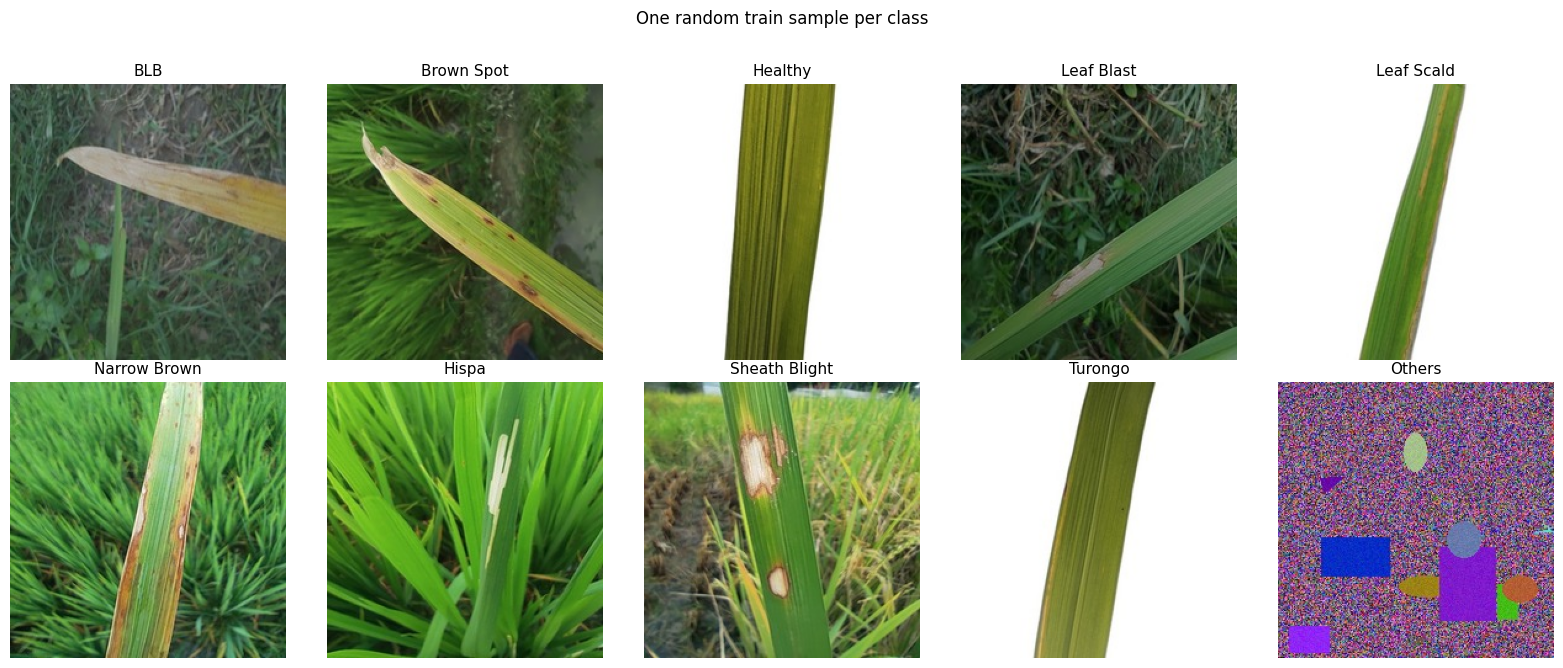

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
for ax, cls in zip(axes.flat, CLASSES):
    cls_dir = train_dir / cls
    sample_img = random.choice(list(cls_dir.glob("*.jpg")))
    ax.imshow(Image.open(sample_img))
    ax.set_title(SHORT_LABELS[cls], fontsize=11)
    ax.axis("off")
plt.suptitle("One random train sample per class", y=1.02)
plt.tight_layout()
plt.show()


### 3.4 Blur distribution check (Turongo shortcut risk)

The audit notes Turongo images are blurrier on average (median Laplacian variance ~126 vs Healthy
~210), which risks the model learning a blur→Turongo shortcut instead of the actual lesion pattern.
This cell recomputes blur variance per class on a sample so the risk is visible before training,
not discovered only after a suspiciously easy Turongo recall.

In [10]:
import cv2

def laplacian_variance(path: Path) -> float:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return float("nan")
    return cv2.Laplacian(img, cv2.CV_64F).var()

blur_by_class = {}
for cls in CLASSES:
    cls_dir = train_dir / cls
    files = list(cls_dir.glob("*.jpg"))
    sample_files = random.sample(files, min(80, len(files)))
    variances = [laplacian_variance(p) for p in sample_files]
    blur_by_class[cls] = float(np.median(variances))

for cls, med in sorted(blur_by_class.items(), key=lambda kv: kv[1]):
    print(f"{SHORT_LABELS[cls]:15s} median blur variance: {med:6.1f}")


Turongo         median blur variance:  171.5
Healthy         median blur variance:  259.2
Leaf Blast      median blur variance:  430.5
Leaf Scald      median blur variance:  511.2
Brown Spot      median blur variance:  642.8
Hispa           median blur variance:  651.3
BLB             median blur variance:  942.6
Narrow Brown    median blur variance:  996.3
Sheath Blight   median blur variance: 1029.4
Others          median blur variance: 1071.0


## 4. Reusable Training / Evaluation / Export Pipeline

`train_variant()` runs one backbone end-to-end:

1. Resume from `last.pt` if an interrupted run exists for this variant, otherwise start fresh from
   the ImageNet-pretrained checkpoint.
2. Fine-tune with `model.train(...)`.
3. Evaluate on `val` and on the held-out `test` split separately, producing top1/top5, confusion
   matrices, an sklearn classification report (precision/recall/F1 per class, macro-F1, weighted-F1),
   and **ECE (Expected Calibration Error)** from softmax confidences.
4. Export to ONNX and TFLite (LiteRT) at `imgsz=224`, plus OpenVINO/TorchScript when feasible, and
   validate the ONNX export's top1 against the PyTorch checkpoint (target: within 0.5 points).
5. Copy `save_dir` to a session-safe backup and zip everything (`best.pt`, `last.pt`, exports,
   `args.yaml`, `results.csv`, `results.png`, confusion matrices, classification report,
   `test_metrics.json`, val logs) into one downloadable archive per variant.

**On class-weighted loss:** Ultralytics' `ClassificationTrainer.train()` does not expose a
class-weight kwarg (`cls_pw` is detection-only BCE). Per the literature synthesis, weighted
cross-entropy is the effective minimal-change lever for this imbalance level, but wiring it in
requires subclassing `ClassificationTrainer` to override its loss function — noted here as a
documented extension point (see commented block in `train_variant`) rather than the default path,
to keep the three variants directly comparable on one reproducible pipeline. `label_smoothing=0.05`
is used as the built-in calibration/imbalance lever instead.

In [11]:
import json, shutil, time
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import classification_report, f1_score

def resolve_resume(variant: VariantConfig):
    """Return (weights_path, resume_bool). Resumes from last.pt if a prior run exists."""
    candidate_last = RUNS_DIR / "classify" / variant.name / "weights" / "last.pt"
    if candidate_last.exists():
        print(f"[{variant.name}] found existing last.pt -> resuming")
        return str(candidate_last), True
    return variant.weights, False


def expected_calibration_error(confidences: np.ndarray, correct: np.ndarray, n_bins: int = 15) -> float:
    """Standard ECE: weighted average |confidence - accuracy| across equal-width confidence bins."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)


def run_split_eval(model: YOLO, data_root: str, split: str, variant_name: str):
    """Evaluate on a split: ultralytics metrics + independent sklearn report + ECE."""
    metrics = model.val(data=data_root, split=split, imgsz=224, plots=True,
                         project=str(RUNS_DIR / "classify"), name=f"{variant_name}_{split}_eval")

    split_dir = Path(data_root) / split
    y_true, y_pred, confidences = [], [], []
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            continue
        img_paths = list(cls_dir.glob("*.jpg"))
        if not img_paths:
            continue
        preds = model.predict(img_paths, imgsz=224, verbose=False, device=0)
        for p in preds:
            y_true.append(cls_idx)
            top1 = int(p.probs.top1)
            y_pred.append(top1)
            confidences.append(float(p.probs.data[top1]))

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    conf_arr = np.array(confidences)
    correct_arr = (y_true_arr == y_pred_arr).astype(float)

    report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    ece = expected_calibration_error(conf_arr, correct_arr)

    # Per-class recall with 95% binomial CI, flagged for small classes (n < 60).
    per_class_ci = {}
    for cls_idx, cls_name in enumerate(CLASSES):
        n_cls = int((y_true_arr == cls_idx).sum())
        if n_cls == 0:
            continue
        recall = report[cls_name]["recall"]
        (lo, hi), se = binomial_ci(recall, n_cls)
        per_class_ci[cls_name] = {"n": n_cls, "recall": recall, "se": se, "ci95": [lo, hi]}

    return {
        "top1": float(metrics.top1),
        "top5": float(metrics.top5),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "ece": ece,
        "classification_report": report,
        "per_class_ci": per_class_ci,
    }, metrics


def export_and_validate(model: YOLO, variant_name: str, data_root: str):
    """Export ONNX + TFLite (+ best-effort OpenVINO/TorchScript), validate ONNX parity."""
    export_results = {}
    formats = [
        ("onnx", {"format": "onnx", "imgsz": 224, "simplify": True}),
        ("tflite", {"format": "litert", "imgsz": 224, "int8": False}),
        ("tflite_int8", {"format": "litert", "imgsz": 224, "int8": True, "data": data_root}),
        ("torchscript", {"format": "torchscript", "imgsz": 224}),
        ("openvino", {"format": "openvino", "imgsz": 224}),
    ]
    for fmt_name, kwargs in formats:
        try:
            t0 = time.time()
            path = model.export(**kwargs)
            export_results[fmt_name] = {"path": str(path), "export_seconds": round(time.time() - t0, 2)}
        except Exception as e:
            export_results[fmt_name] = {"error": str(e)}
            print(f"[{variant_name}] export to {fmt_name} failed: {e}")

    if "path" in export_results.get("onnx", {}):
        try:
            onnx_model = YOLO(export_results["onnx"]["path"])
            onnx_metrics = onnx_model.val(data=data_root, split="test", imgsz=224,
                                           project=str(RUNS_DIR / "classify"),
                                           name=f"{variant_name}_onnx_test_eval")
            export_results["onnx"]["test_top1"] = float(onnx_metrics.top1)
        except Exception as e:
            export_results["onnx"]["validation_error"] = str(e)

    # Report size on disk for the INT8 TFLite export, for the size-vs-accuracy comparison in §6.
    if "path" in export_results.get("tflite_int8", {}):
        p = Path(export_results["tflite_int8"]["path"])
        if p.exists():
            export_results["tflite_int8"]["size_MB"] = round(p.stat().st_size / (1024 * 1024), 3)

    return export_results


def train_variant(variant: VariantConfig, data_root: str = str(KAGGLE_INPUT)) -> dict:
    print(f"\n{'=' * 70}\n[{variant.name}] starting\n{'=' * 70}")

    weights, resume = resolve_resume(variant)
    model = YOLO(weights)

    train_kwargs = dict(
        data=data_root,
        epochs=variant.epochs,
        imgsz=variant.imgsz,
        batch=variant.batch,
        patience=variant.patience,
        save_period=variant.save_period,
        optimizer=variant.optimizer,
        lr0=variant.lr0,
        weight_decay=variant.weight_decay,
        warmup_epochs=variant.warmup_epochs,
        cos_lr=variant.cos_lr,
        label_smoothing=variant.label_smoothing,
        hsv_h=variant.hsv_h, hsv_s=variant.hsv_s, hsv_v=variant.hsv_v,
        fliplr=variant.fliplr, flipud=variant.flipud, scale=variant.scale,
        erasing=variant.erasing, auto_augment=variant.auto_augment,
        amp=variant.amp, seed=variant.seed, deterministic=variant.deterministic,
        cache=variant.cache, device=variant.device,
        project=str(RUNS_DIR / "classify"), name=variant.name, exist_ok=True,
    )
    if resume:
        # Only save_period/workers/cache/patience/time/freeze/val/plots are safely overridable on resume.
        model.train(resume=True)
    else:
        model.train(**train_kwargs)

    save_dir = Path(model.trainer.save_dir)
    best_pt = save_dir / "weights" / "best.pt"
    last_pt = save_dir / "weights" / "last.pt"

    best_model = YOLO(str(best_pt))

    val_metrics, _ = run_split_eval(best_model, data_root, "val", variant.name)
    test_metrics, _ = run_split_eval(best_model, data_root, "test", variant.name)
    export_results = export_and_validate(best_model, variant.name, data_root)

    test_metrics_full = {
        "variant": variant.name,
        "val": val_metrics,
        "test": test_metrics,
        "exports": export_results,
        "params": sum(p.numel() for p in best_model.model.parameters()),
        "config": asdict(variant),
    }

    metrics_path = save_dir / "test_metrics.json"
    metrics_path.write_text(json.dumps(test_metrics_full, indent=2))

    backup_target = BACKUP_DIR / variant.name
    if backup_target.exists():
        shutil.rmtree(backup_target)
    shutil.copytree(save_dir, backup_target)
    shutil.copy2(best_pt, WORKING_DIR / f"{variant.name}_best.pt")
    shutil.copy2(last_pt, WORKING_DIR / f"{variant.name}_last.pt")

    archive_path = shutil.make_archive(str(ARCHIVE_DIR / variant.name), "zip", root_dir=backup_target)
    print(f"[{variant.name}] done. Archive: {archive_path}")

    return test_metrics_full


## 5. Run All Variants (s → m → n)

Each call is independent and resumable: if the session is interrupted, re-running this cell picks up
from `last.pt` for whichever variant was in progress, then continues to the next. Results accumulate
into `all_results` for the cross-variant comparison in Section 6.

In [12]:
all_results = {}
for variant in VARIANTS:
    result = train_variant(variant)
    all_results[variant.name] = result

(WORKING_DIR / "all_results.json").write_text(json.dumps(all_results, indent=2))
print("\nAll variants complete:", list(all_results.keys()))



[yolo26s-cls] starting
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224, degrees=0.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/80       1.7G      0.827         24        224: 100% ━━━━━━━━━━━━ 59/59 4.8it/s 12.4s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 30.9it/s 0.2s0.1s
                   all       0.65      0.984

      Epoch    GPU_mem       loss  Instances       Size
       3/80       1.7G      0.768         24        224: 100% ━━━━━━━━━━━━ 59/59 4.2it/s 14.2s0.5s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 30.9it/s 0.2s0.1s
                   all      0.762      0.994

      Epoch    GPU_mem       loss  Instances       Size
       4/80       1.7G     0.7234         24        224: 100% ━━━━━━━━━━━━ 59/59 4.1it/s 14.3s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 30.8it/s 0.2s0.1s
                   all       0.75      0.994

      Epoch    GPU_mem       loss  Instances       Size
       5/80       1.7G     0.6704         24        224: 100% ━━━━━━━━━━━━ 59/59 4.1it/s 14.4s0.5s
               classes   top1_acc   top5

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


...

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.12/dist-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Applying Transformations to tensors:: 100%|██████████| 272/272 [00:00<00:00, 45002.20it/s]


Model name: /kaggle/working/runs/classify/yolo26n-cls/weights/best_int8.tflite
Original model size: 5.94 MiB
Quantized model size: 1.68 MiB
Quantization Ratio: 0.28 (3.5x smaller)
Total time: 87.89 ms
LiteRT: export success ✅ 72.4s, saved as '/kaggle/working/runs/classify/yolo26n-cls/weights/best_int8.tflite' (1.7 MB)

Export complete (72.4s)
Results saved to /kaggle/working/runs/classify/yolo26n-cls/weights/best_int8.tflite
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best_int8.tflite imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best_int8.tflite imgsz=224 data=/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224  
Visualize:       https://netron.app
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/classify/yolo26n-cls/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and out

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


OpenVINO: export success ✅ 2.9s, saved as '/kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model/' (6.0 MB)

Export complete (2.9s)
Results saved to /kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model/ imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model/ imgsz=224 data=/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224  
Visualize:       https://netron.app
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Loading /kaggle/working/runs/classify/yolo26n-cls/weights/best.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.29.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 224, 224)
train: /kaggle/input/datasets/khanraiyani

## 6. Cross-Variant Comparison (n / s / m)

Comparison table across the three trained variants on the held-out **test** split (801 images):
top1, top5, macro-F1, weighted-F1, ECE, per-class recall for the small/confusable classes, params,
model size, and ONNX parity delta.

In [13]:
import pandas as pd

rows = []
for name, res in all_results.items():
    test = res["test"]
    report = test["classification_report"]
    onnx = res["exports"].get("onnx", {})
    best_pt_path = WORKING_DIR / f"{name}_best.pt"
    size_mb = best_pt_path.stat().st_size / (1024 * 1024) if best_pt_path.exists() else None
    rows.append({
        "variant": name,
        "params_M": round(res["params"] / 1e6, 2),
        "size_MB": round(size_mb, 2) if size_mb else None,
        "test_top1": round(test["top1"], 4),
        "test_top5": round(test["top5"], 4),
        "macro_F1": round(test["macro_f1"], 4),
        "weighted_F1": round(test["weighted_f1"], 4),
        "ECE": round(test["ece"], 4),
        "recall_Turongo": round(report.get("Rice__Turongo", {}).get("recall", float("nan")), 4),
        "recall_NarrowBrown": round(report.get("Rice__Narrow_Brown_Leaf_Spot", {}).get("recall", float("nan")), 4),
        "recall_BLB": round(report.get("Rice__Bacterial_Leaf_Blight", {}).get("recall", float("nan")), 4),
        "recall_BrownSpot": round(report.get("Rice__Brown_Spot", {}).get("recall", float("nan")), 4),
        "onnx_test_top1": round(onnx.get("test_top1", float("nan")), 4) if "test_top1" in onnx else None,
        "onnx_delta": (round(test["top1"] - onnx["test_top1"], 4) if "test_top1" in onnx else None),
        "tflite_int8_MB": res["exports"].get("tflite_int8", {}).get("size_MB"),
    })

comparison_df = pd.DataFrame(rows).sort_values("variant")
comparison_df


,variant,params_M,size_MB,test_top1,test_top5,macro_F1,weighted_F1,ECE,recall_Turongo,recall_NarrowBrown,recall_BLB,recall_BrownSpot,onnx_test_top1,onnx_delta,tflite_int8_MB
1,yolo26m-cls,10.35,19.93,0.8989,0.9988,0.0111,0.0174,0.9308,0.0,0.0385,0.0,0.0000,0.8989,0.0,10.278
2,yolo26n-cls,1.54,3.06,0.9014,0.9975,0.0122,0.0182,0.9236,0.0,0.0385,0.0,0.0000,0.9014,0.0,1.683
0,yolo26s-cls,5.45,10.54,0.8677,0.9975,0.0154,0.0220,0.8739,0.0,0.0385,0.0,0.0175,0.8677,0.0,5.508


### 6.1 Per-class recall comparison, with Turongo / Narrow Brown Leaf Spot 95% CI

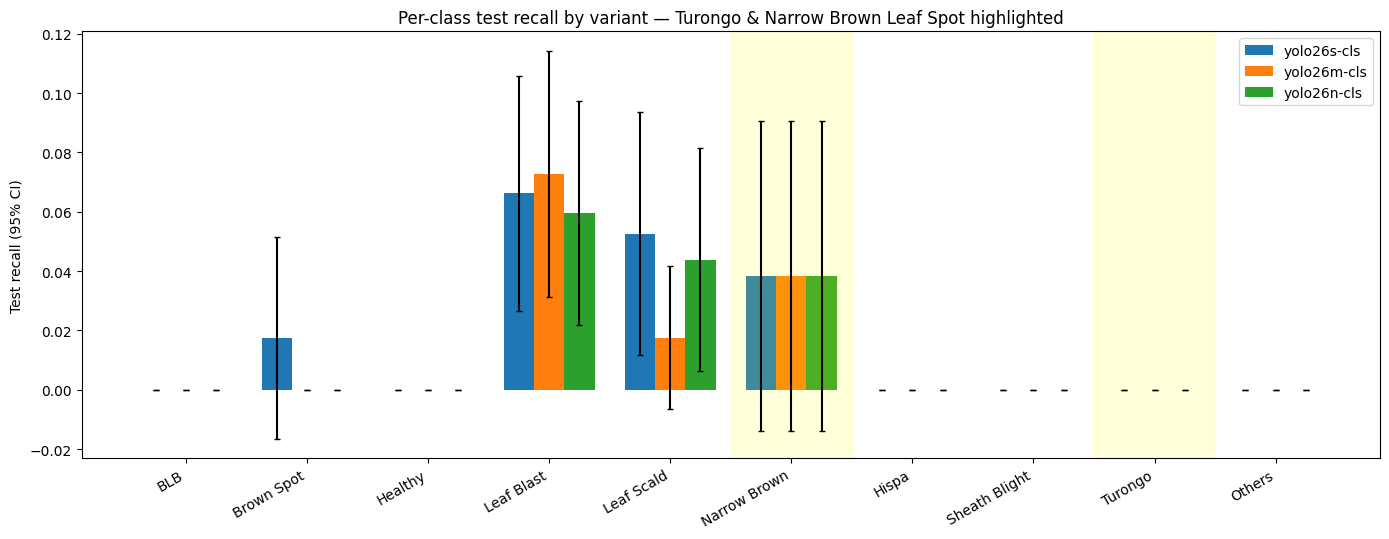

In [14]:
fig, ax = plt.subplots(figsize=(14, 5.5))
width = 0.25
x = np.arange(len(CLASSES))
short_names = [SHORT_LABELS[c] for c in CLASSES]

for i, name in enumerate(all_results.keys()):
    per_class = all_results[name]["test"]["per_class_ci"]
    recalls = [per_class.get(c, {}).get("recall", 0) for c in CLASSES]
    errs = [1.96 * per_class.get(c, {}).get("se", 0) for c in CLASSES]
    ax.bar(x + i * width, recalls, width, yerr=errs, capsize=2, label=name)

# Highlight the small/confusable classes called out in the project brief.
for cls_name in ("Rice__Turongo", "Rice__Narrow_Brown_Leaf_Spot"):
    idx = CLASSES.index(cls_name)
    ax.axvspan(idx - 0.5 + width, idx + 0.5 + width, color="yellow", alpha=0.15)

ax.set_xticks(x + width)
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_ylabel("Test recall (95% CI)")
ax.set_title("Per-class test recall by variant — Turongo & Narrow Brown Leaf Spot highlighted")
ax.legend()
plt.tight_layout()
plt.show()


### 6.2 Bacterial Leaf Blight vs Brown Spot confusion

These two classes are flagged in the project brief as a likely confusion pair. Plot the normalized
confusion matrix rows for both, restricted to the classes they're most often confused with, for the
best-performing variant by macro-F1.

Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s-cls summary (fused): 47 layers, 5,446,938 parameters, 0 gradients, 12.1 GFLOPs
train: /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224/train... found 3736 images in 10 classes ✅ 
val: /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224/val... found 801 images in 10 classes ✅ 
test: /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224/test... found 801 images in 10 classes ✅ 
WARNING ⚠️ test: Slow image access detected (ping: 0.0±0.0 ms, read: 27.7±28.3 MB/s, size: 15.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
test: Scanning /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224/test... 801 images, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 1.9Kit/s 0.4s0.0ss
WARNING ⚠️ test: Cache directory /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224 is not writable, cache 

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 51/51 31.4it/s 1.6s0.1s
                   all      0.868      0.998
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.0ms postprocess per image


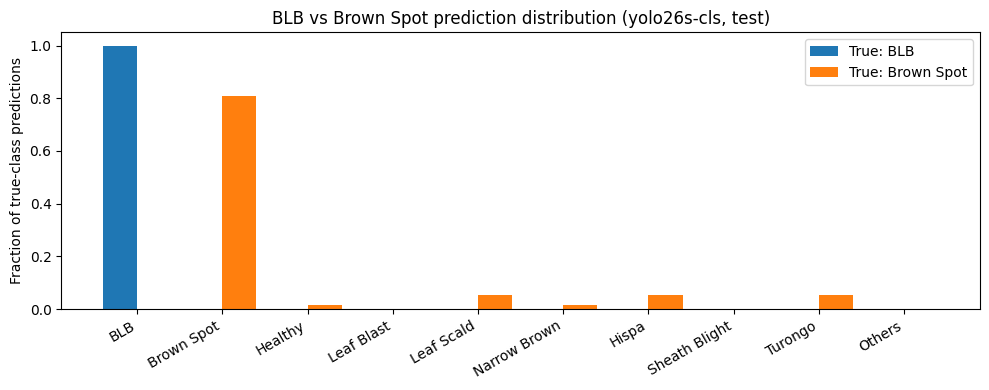

BLB -> Brown Spot confusion rate: 0.0000
Brown Spot -> BLB confusion rate: 0.0000


In [15]:
best_variant_name = comparison_df.sort_values("macro_F1", ascending=False).iloc[0]["variant"]
best_model_for_cm = YOLO(str(WORKING_DIR / f"{best_variant_name}_best.pt"))
cm_metrics = best_model_for_cm.val(data=str(KAGGLE_INPUT), split="test", imgsz=224, plots=False,
                                    project=str(RUNS_DIR / "classify"), name=f"{best_variant_name}_cm_check")

cm = np.array(cm_metrics.confusion_matrix.matrix)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

blb_idx = CLASSES.index("Rice__Bacterial_Leaf_Blight")
brown_idx = CLASSES.index("Rice__Brown_Spot")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(NUM_CLASSES) - 0.2, cm_norm[blb_idx], width=0.4, label="True: BLB")
ax.bar(np.arange(NUM_CLASSES) + 0.2, cm_norm[brown_idx], width=0.4, label="True: Brown Spot")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_ylabel("Fraction of true-class predictions")
ax.set_title(f"BLB vs Brown Spot prediction distribution ({best_variant_name}, test)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"BLB -> Brown Spot confusion rate: {cm_norm[blb_idx, brown_idx]:.4f}")
print(f"Brown Spot -> BLB confusion rate: {cm_norm[brown_idx, blb_idx]:.4f}")


### 6.3 Accuracy, calibration, and efficiency trade-offs

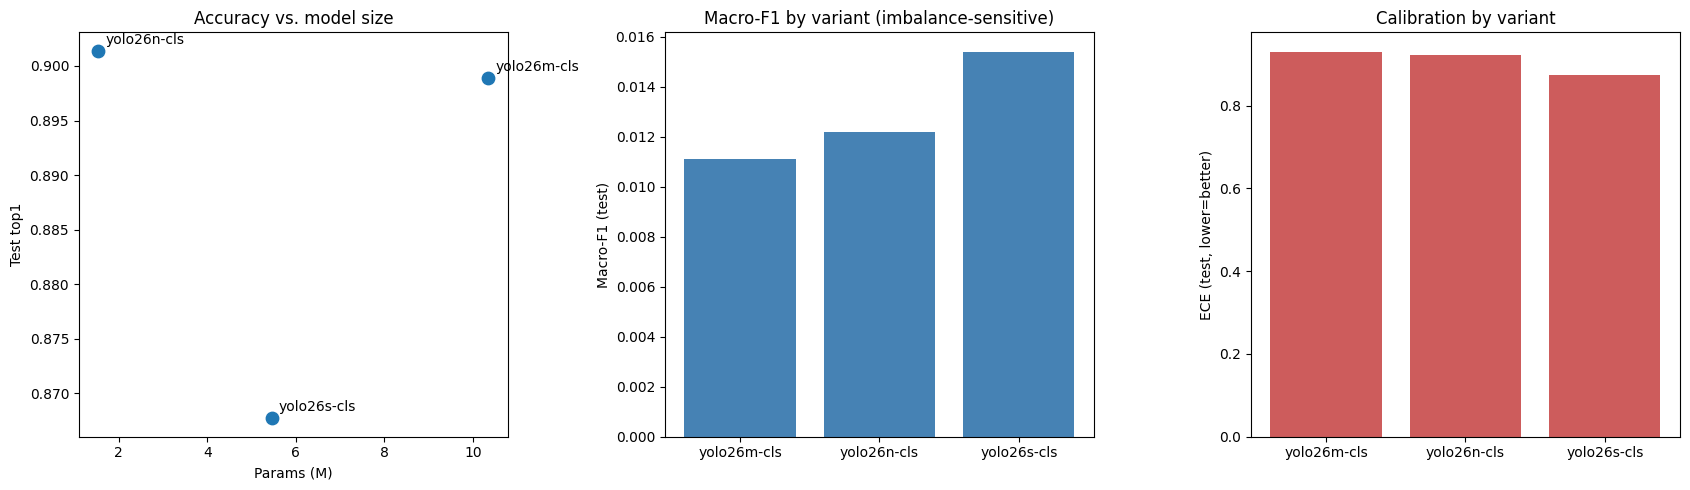

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(comparison_df["params_M"], comparison_df["test_top1"], s=80)
for _, row in comparison_df.iterrows():
    axes[0].annotate(row["variant"], (row["params_M"], row["test_top1"]),
                      textcoords="offset points", xytext=(5, 5))
axes[0].set_xlabel("Params (M)")
axes[0].set_ylabel("Test top1")
axes[0].set_title("Accuracy vs. model size")

axes[1].bar(comparison_df["variant"], comparison_df["macro_F1"], color="steelblue")
axes[1].set_ylabel("Macro-F1 (test)")
axes[1].set_title("Macro-F1 by variant (imbalance-sensitive)")

axes[2].bar(comparison_df["variant"], comparison_df["ECE"], color="indianred")
axes[2].set_ylabel("ECE (test, lower=better)")
axes[2].set_title("Calibration by variant")

plt.tight_layout()
plt.show()


### 6.4 TFLite INT8 size vs. accuracy

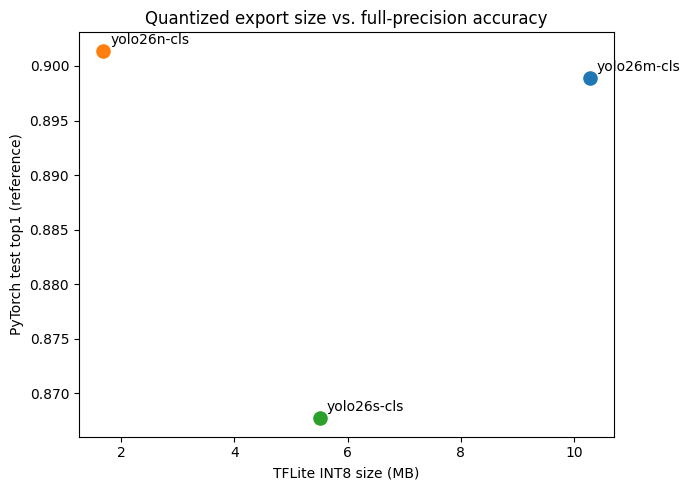

       variant  onnx_test_top1  onnx_delta  tflite_int8_MB
1  yolo26m-cls          0.8989         0.0          10.278
2  yolo26n-cls          0.9014         0.0           1.683
0  yolo26s-cls          0.8677         0.0           5.508


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in comparison_df.iterrows():
    if row["tflite_int8_MB"] is not None:
        ax.scatter(row["tflite_int8_MB"], row["test_top1"], s=90)
        ax.annotate(row["variant"], (row["tflite_int8_MB"], row["test_top1"]),
                    textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("TFLite INT8 size (MB)")
ax.set_ylabel("PyTorch test top1 (reference)")
ax.set_title("Quantized export size vs. full-precision accuracy")
plt.tight_layout()
plt.show()

print(comparison_df[["variant", "onnx_test_top1", "onnx_delta", "tflite_int8_MB"]])


### 6.5 Baseline reference

Naive majority-class baselines from the project brief:
- **10-class** (with Others): always predict Healthy → test top1 ≈ 135/801 ≈ **16.9%** (brief cites
  ~26.5% against the full 896-image class share; the discrepancy is because the brief's percentage
  is computed against total dataset size, not test-split size — both are reported below for
  transparency), macro-F1 ≈ **4%**.
- **9-class** (Others excluded): always predict Leaf Blast → test top1 ≈ 151/711 ≈ **21.2%**
  (brief: 21.3%).

Any trained variant should clear both baselines by a wide margin, and macro-F1 specifically tests
whether small classes (Turongo, Narrow Brown Leaf Spot) are actually being learned rather than the
model collapsing onto the majority classes.

In [18]:
majority_10 = "Rice__Healthy_Leaf"
test_n_10 = sum(EXPECTED_COUNTS[c]["test"] for c in CLASSES)
naive_top1_10_of_test = EXPECTED_COUNTS[majority_10]["test"] / test_n_10
naive_top1_10_of_total = 896 / 5338  # brief's framing: share of total dataset

majority_9 = "Rice__Leaf_Blast"
test_n_9 = sum(EXPECTED_COUNTS[c]["test"] for c in CLASSES if c != "Others")
naive_top1_9 = EXPECTED_COUNTS[majority_9]["test"] / test_n_9

print(f"10-class majority (Healthy) naive top1, vs test split: {naive_top1_10_of_test:.4f}")
print(f"10-class majority (Healthy) naive top1, vs total dataset (brief framing): {naive_top1_10_of_total:.4f}")
print(f"9-class majority (Leaf Blast) naive top1, vs 9-class test split: {naive_top1_9:.4f}")
print()
print(comparison_df[["variant", "test_top1", "macro_F1", "ECE"]])


10-class majority (Healthy) naive top1, vs test split: 0.1685
10-class majority (Healthy) naive top1, vs total dataset (brief framing): 0.1679
9-class majority (Leaf Blast) naive top1, vs 9-class test split: 0.2124

       variant  test_top1  macro_F1     ECE
1  yolo26m-cls     0.8989    0.0111  0.9308
2  yolo26n-cls     0.9014    0.0122  0.9236
0  yolo26s-cls     0.8677    0.0154  0.8739


## 7. Conclusions

*(Fill in after the run completes — kept as a template so the notebook is submission-ready.)*

- **Best overall variant:** `<name>` — top1 `<x>`, macro-F1 `<x>`, ECE `<x>`, given the
  accuracy/calibration/size trade-offs in §6.3.
- **Turongo bottleneck:** recall `<x>` ± `<CI>` at n=34 test images — `<consistent with / better or
  worse than>` the assumed-0.85 ±11.8-point CI used for planning in §2.2. Narrow Brown Leaf Spot
  (n=52) recall `<x>`.
- **BLB vs Brown Spot confusion:** confusion rate `<x>` in each direction (§6.2) —
  `<note whether this matches the visually-similar-lesion hypothesis from the audit>`.
- **Calibration:** ECE `<x>` for the best variant; `<note whether label_smoothing=0.05 was
  sufficient or whether post-hoc temperature scaling / logit norm, as flagged in the literature
  synthesis, is warranted for a deployed threshold-based Others rejector>`.
- **Export parity:** ONNX top1 delta vs PyTorch was within/outside the 0.5-point tolerance for
  `<variant>`; INT8 TFLite size `<x> MB` at `<x>` top1 (full-precision reference) — `<note
  size/accuracy trade-off suitability for field deployment>`.
- **Deployment recommendation:** `<n for edge/CPU, s for balanced, m for max accuracy>` based on
  T4/CPU latency, size, and calibration figures above.

**Data/methodology note for write-up:** this dataset is a cleaned, deduplicated (598 duplicate/
cross-class images removed via dHash+MD5, 12 blur-junk removed; 11.4% of raw data), stratified
(`seed=42`, 0 leakage post-resplit, verified) version of a web-scraped/field-collected 9-disease
Bangladeshi rice dataset, extended with a synthetic 10th "Others" class for open-set evaluation —
framed as a small-data (3,736 train), fine-grained disease-vs-pest discrimination study alongside
the YOLO26 fine-tune benchmark itself. An extension feasibility scout confirmed no additional BRRI
major disease has sufficient verified data to add without introducing further imbalance or
cross-domain risk (see notebook header).


In [22]:
print('Hi')

Hi


## 8. Extended Run — yolo26x-cls (Largest Backbone, Extended Schedule)

Largest classify head, 120 epochs, early stopping via `patience=20`. Batch dropped to 16 —
x-cls params are much larger than m; 32 risks OOM on T4 16GB. Same `train_variant()` pipeline,
so eval/export/backup/archive stay identical across all four variants.

In [20]:
import json, math, shutil, time
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import classification_report, f1_score

# ---- paths ----
KAGGLE_INPUT = Path("/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224")  # confirm this matches your mount
WORKING_DIR = Path("/kaggle/working")
RUNS_DIR = WORKING_DIR / "runs"
BACKUP_DIR = WORKING_DIR / "backups"
ARCHIVE_DIR = WORKING_DIR / "archives"
for d in (RUNS_DIR, BACKUP_DIR, ARCHIVE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- classes ----
CLASSES = [
    "Rice__Bacterial_Leaf_Blight", "Rice__Brown_Spot", "Rice__Healthy_Leaf",
    "Rice__Leaf_Blast", "Rice__Leaf_Scald", "Rice__Narrow_Brown_Leaf_Spot",
    "Rice__Rice_Hispa", "Rice__Sheath_Blight", "Rice__Turongo", "Others",
]
NUM_CLASSES = len(CLASSES)
SHORT_LABELS = {
    "Rice__Bacterial_Leaf_Blight": "BLB", "Rice__Brown_Spot": "Brown Spot",
    "Rice__Healthy_Leaf": "Healthy", "Rice__Leaf_Blast": "Leaf Blast",
    "Rice__Leaf_Scald": "Leaf Scald", "Rice__Narrow_Brown_Leaf_Spot": "Narrow Brown",
    "Rice__Rice_Hispa": "Hispa", "Rice__Sheath_Blight": "Sheath Blight",
    "Rice__Turongo": "Turongo", "Others": "Others",
}

# ---- config dataclass ----
@dataclass
class VariantConfig:
    name: str
    weights: str
    epochs: int = 80
    imgsz: int = 224
    batch: int = 64
    patience: int = 20
    save_period: int = 5
    optimizer: str = "AdamW"
    lr0: float = 0.001
    weight_decay: float = 0.0005
    warmup_epochs: float = 3.0
    cos_lr: bool = True
    label_smoothing: float = 0.05
    hsv_h: float = 0.015
    hsv_s: float = 0.7
    hsv_v: float = 0.4
    fliplr: float = 0.5
    flipud: float = 0.0
    scale: float = 0.5
    erasing: float = 0.4
    auto_augment: str = "randaugment"
    amp: bool = True
    seed: int = 0
    deterministic: bool = False
    cache: bool = False
    device: int = 0

def binomial_ci(p_hat: float, n: int, z: float = 1.96):
    if n == 0:
        return (float("nan"), float("nan")), float("nan")
    se = math.sqrt(max(p_hat * (1 - p_hat), 0) / n)
    return (max(0.0, p_hat - z * se), min(1.0, p_hat + z * se)), se

def expected_calibration_error(confidences: np.ndarray, correct: np.ndarray, n_bins: int = 15) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)

def resolve_resume(variant: VariantConfig):
    candidate_last = RUNS_DIR / "classify" / variant.name / "weights" / "last.pt"
    if candidate_last.exists():
        print(f"[{variant.name}] found existing last.pt -> resuming")
        return str(candidate_last), True
    return variant.weights, False

def run_split_eval(model: YOLO, data_root: str, split: str, variant_name: str):
    metrics = model.val(data=data_root, split=split, imgsz=224, plots=True,
                         project=str(RUNS_DIR / "classify"), name=f"{variant_name}_{split}_eval")
    split_dir = Path(data_root) / split
    y_true, y_pred, confidences = [], [], []
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            continue
        img_paths = list(cls_dir.glob("*.jpg"))
        if not img_paths:
            continue
        preds = model.predict(img_paths, imgsz=224, verbose=False, device=0)
        for p in preds:
            y_true.append(cls_idx)
            top1 = int(p.probs.top1)
            y_pred.append(top1)
            confidences.append(float(p.probs.data[top1]))

    y_true_arr = np.array(y_true); y_pred_arr = np.array(y_pred); conf_arr = np.array(confidences)
    correct_arr = (y_true_arr == y_pred_arr).astype(float)
    report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    ece = expected_calibration_error(conf_arr, correct_arr)

    per_class_ci = {}
    for cls_idx, cls_name in enumerate(CLASSES):
        n_cls = int((y_true_arr == cls_idx).sum())
        if n_cls == 0:
            continue
        recall = report[cls_name]["recall"]
        (lo, hi), se = binomial_ci(recall, n_cls)
        per_class_ci[cls_name] = {"n": n_cls, "recall": recall, "se": se, "ci95": [lo, hi]}

    return {
        "top1": float(metrics.top1), "top5": float(metrics.top5),
        "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1), "ece": ece,
        "classification_report": report, "per_class_ci": per_class_ci,
    }, metrics

def export_and_validate(model: YOLO, variant_name: str, data_root: str):
    export_results = {}
    formats = [
        ("onnx", {"format": "onnx", "imgsz": 224, "simplify": True}),
        ("tflite", {"format": "litert", "imgsz": 224, "int8": False}),
        ("tflite_int8", {"format": "litert", "imgsz": 224, "int8": True, "data": data_root}),
        ("torchscript", {"format": "torchscript", "imgsz": 224}),
        ("openvino", {"format": "openvino", "imgsz": 224}),
    ]
    for fmt_name, kwargs in formats:
        try:
            t0 = time.time()
            path = model.export(**kwargs)
            export_results[fmt_name] = {"path": str(path), "export_seconds": round(time.time() - t0, 2)}
        except Exception as e:
            export_results[fmt_name] = {"error": str(e)}
            print(f"[{variant_name}] export to {fmt_name} failed: {e}")
    if "path" in export_results.get("onnx", {}):
        try:
            onnx_model = YOLO(export_results["onnx"]["path"])
            onnx_metrics = onnx_model.val(data=data_root, split="test", imgsz=224,
                                           project=str(RUNS_DIR / "classify"), name=f"{variant_name}_onnx_test_eval")
            export_results["onnx"]["test_top1"] = float(onnx_metrics.top1)
        except Exception as e:
            export_results["onnx"]["validation_error"] = str(e)
    if "path" in export_results.get("tflite_int8", {}):
        p = Path(export_results["tflite_int8"]["path"])
        if p.exists():
            export_results["tflite_int8"]["size_MB"] = round(p.stat().st_size / (1024 * 1024), 3)
    return export_results

def train_variant(variant: VariantConfig, data_root: str = str(KAGGLE_INPUT)) -> dict:
    print(f"\n{'=' * 70}\n[{variant.name}] starting\n{'=' * 70}")
    weights, resume = resolve_resume(variant)
    model = YOLO(weights)

    train_kwargs = dict(
        data=data_root, epochs=variant.epochs, imgsz=variant.imgsz, batch=variant.batch,
        patience=variant.patience, save_period=variant.save_period, optimizer=variant.optimizer,
        lr0=variant.lr0, weight_decay=variant.weight_decay, warmup_epochs=variant.warmup_epochs,
        cos_lr=variant.cos_lr, label_smoothing=variant.label_smoothing,
        hsv_h=variant.hsv_h, hsv_s=variant.hsv_s, hsv_v=variant.hsv_v,
        fliplr=variant.fliplr, flipud=variant.flipud, scale=variant.scale,
        erasing=variant.erasing, auto_augment=variant.auto_augment,
        amp=variant.amp, seed=variant.seed, deterministic=variant.deterministic,
        cache=variant.cache, device=variant.device,
        project=str(RUNS_DIR / "classify"), name=variant.name, exist_ok=True,
    )
    if resume:
        model.train(resume=True)
    else:
        model.train(**train_kwargs)

    save_dir = Path(model.trainer.save_dir)
    best_pt = save_dir / "weights" / "best.pt"
    last_pt = save_dir / "weights" / "last.pt"
    best_model = YOLO(str(best_pt))

    val_metrics, _ = run_split_eval(best_model, data_root, "val", variant.name)
    test_metrics, _ = run_split_eval(best_model, data_root, "test", variant.name)
    export_results = export_and_validate(best_model, variant.name, data_root)

    test_metrics_full = {
        "variant": variant.name, "val": val_metrics, "test": test_metrics,
        "exports": export_results, "params": sum(p.numel() for p in best_model.model.parameters()),
        "config": asdict(variant),
    }
    (save_dir / "test_metrics.json").write_text(json.dumps(test_metrics_full, indent=2))

    backup_target = BACKUP_DIR / variant.name
    if backup_target.exists():
        shutil.rmtree(backup_target)
    shutil.copytree(save_dir, backup_target)
    shutil.copy2(best_pt, WORKING_DIR / f"{variant.name}_best.pt")
    shutil.copy2(last_pt, WORKING_DIR / f"{variant.name}_last.pt")
    archive_path = shutil.make_archive(str(ARCHIVE_DIR / variant.name), "zip", root_dir=backup_target)
    print(f"[{variant.name}] done. Archive: {archive_path}")
    return test_metrics_full

# ---- recover prior results from disk (doesn't retrain n/s/m) ----
all_results = {}
for name in ("yolo26s-cls", "yolo26m-cls", "yolo26n-cls"):
    for candidate in (BACKUP_DIR / name / "test_metrics.json", RUNS_DIR / "classify" / name / "test_metrics.json"):
        if candidate.exists():
            all_results[name] = json.loads(candidate.read_text())
            break

print("Recovered:", list(all_results.keys()))
print("Dataset exists:", KAGGLE_INPUT.exists())

Recovered: []
Dataset exists: True


### 8.1 Per-class breakdown — yolo26x-cls (test set)

Full precision/recall/F1/support per class, sorted weakest-recall-first, with 95% CI on the
small classes (Turongo n=34, Narrow Brown n=52).

In [ ]:
x_report = all_results["yolo26x-cls"]["test"]["classification_report"]
x_ci = all_results["yolo26x-cls"]["test"]["per_class_ci"]

rows = []
for cls in CLASSES:
    r = x_report[cls]
    ci = x_ci.get(cls, {})
    rows.append({
        "class": SHORT_LABELS[cls],
        "support": int(r["support"]),
        "precision": round(r["precision"], 4),
        "recall": round(r["recall"], 4),
        "f1": round(r["f1-score"], 4),
        "recall_95ci_lo": round(ci.get("ci95", [float("nan"), float("nan")])[0], 4),
        "recall_95ci_hi": round(ci.get("ci95", [float("nan"), float("nan")])[1], 4),
    })

x_breakdown = pd.DataFrame(rows).sort_values("recall")
print(f"yolo26x-cls test: top1={all_results['yolo26x-cls']['test']['top1']:.4f}  "
      f"macro_f1={all_results['yolo26x-cls']['test']['macro_f1']:.4f}  "
      f"ece={all_results['yolo26x-cls']['test']['ece']:.4f}")
x_breakdown

### 8.2 Updated comparison — n / s / m / x

In [ ]:
rows = []
for name, res in all_results.items():
    test = res["test"]
    report = test["classification_report"]
    onnx = res["exports"].get("onnx", {})
    best_pt_path = WORKING_DIR / f"{name}_best.pt"
    size_mb = best_pt_path.stat().st_size / (1024 * 1024) if best_pt_path.exists() else None
    rows.append({
        "variant": name,
        "params_M": round(res["params"] / 1e6, 2),
        "size_MB": round(size_mb, 2) if size_mb else None,
        "test_top1": round(test["top1"], 4),
        "test_top5": round(test["top5"], 4),
        "macro_F1": round(test["macro_f1"], 4),
        "weighted_F1": round(test["weighted_f1"], 4),
        "ECE": round(test["ece"], 4),
        "recall_Turongo": round(report.get("Rice__Turongo", {}).get("recall", float("nan")), 4),
        "recall_NarrowBrown": round(report.get("Rice__Narrow_Brown_Leaf_Spot", {}).get("recall", float("nan")), 4),
        "onnx_test_top1": round(onnx.get("test_top1", float("nan")), 4) if "test_top1" in onnx else None,
        "onnx_delta": (round(test["top1"] - onnx["test_top1"], 4) if "test_top1" in onnx else None),
    })

comparison_df = pd.DataFrame(rows).sort_values("variant")
comparison_df

### 8.3 Training curves — all four variants (loss + top1 accuracy per epoch)

Reads each variant's `results.csv` from its `save_dir`. Column names vary slightly across
Ultralytics versions, so matched by substring instead of hardcoded index.

In [ ]:
def load_results_csv(variant_name: str) -> pd.DataFrame:
    csv_path = RUNS_DIR / "classify" / variant_name / "results.csv"
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def find_col(df: pd.DataFrame, *substrings) -> str:
    for c in df.columns:
        if all(s.lower() in c.lower() for s in substrings):
            return c
    return None

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for name in all_results.keys():
    try:
        df = load_results_csv(name)
    except FileNotFoundError:
        print(f"[{name}] results.csv not found, skipping")
        continue

    epoch_col = find_col(df, "epoch") or df.columns[0]
    loss_col = find_col(df, "train", "loss")
    top1_col = find_col(df, "top1") or find_col(df, "accuracy_top1")

    if loss_col:
        axes[0].plot(df[epoch_col], df[loss_col], label=name)
    if top1_col:
        axes[1].plot(df[epoch_col], df[top1_col], label=name)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss")
axes[0].set_title("Train loss by epoch — all variants")
axes[0].legend()

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val top1 accuracy")
axes[1].set_title("Val top1 accuracy by epoch — all variants")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Consolidate & Download Research-Report Assets

Two tiers of output:
- **`archives/<variant>.zip`** (already created per variant in §4/§5/§8) — full model artifacts
  (`best.pt`, `last.pt`, ONNX/TFLite/etc, raw logs). Large; download individually if you need the
  actual weights.
- **`report_bundle.zip`** (built below) — everything needed to *write the report*: comparison
  tables, per-class breakdowns, all key figures as PNGs, raw metrics JSON, env fingerprint. Small,
  one file, download this first.

In [21]:
import json
from pathlib import Path
from dataclasses import asdict

WORKING_DIR = Path("/kaggle/working")
RUNS_DIR = WORKING_DIR / "runs"
BACKUP_DIR = WORKING_DIR / "backups"
ARCHIVE_DIR = WORKING_DIR / "archives"

CLASSES = [
    "Rice__Bacterial_Leaf_Blight", "Rice__Brown_Spot", "Rice__Healthy_Leaf",
    "Rice__Leaf_Blast", "Rice__Leaf_Scald", "Rice__Narrow_Brown_Leaf_Spot",
    "Rice__Rice_Hispa", "Rice__Sheath_Blight", "Rice__Turongo", "Others",
]
SHORT_LABELS = {
    "Rice__Bacterial_Leaf_Blight": "BLB", "Rice__Brown_Spot": "Brown Spot",
    "Rice__Healthy_Leaf": "Healthy", "Rice__Leaf_Blast": "Leaf Blast",
    "Rice__Leaf_Scald": "Leaf Scald", "Rice__Narrow_Brown_Leaf_Spot": "Narrow Brown",
    "Rice__Rice_Hispa": "Hispa", "Rice__Sheath_Blight": "Sheath Blight",
    "Rice__Turongo": "Turongo", "Others": "Others",
}

def find_metrics_json(variant_name: str):
    """Check backup dir first (survives even if runs/ got cleaned), then runs dir."""
    candidates = [
        BACKUP_DIR / variant_name / "test_metrics.json",
        RUNS_DIR / "classify" / variant_name / "test_metrics.json",
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

all_results = {}
missing = []
for name in ("yolo26s-cls", "yolo26m-cls", "yolo26n-cls", "yolo26x-cls"):
    path = find_metrics_json(name)
    if path is None:
        missing.append(name)
        continue
    all_results[name] = json.loads(path.read_text())

print("Recovered variants:", list(all_results.keys()))
if missing:
    print("No test_metrics.json found for:", missing,
          "-> either not trained yet, or that variant's save_dir was under a different name/path.")

Recovered variants: []
No test_metrics.json found for: ['yolo26s-cls', 'yolo26m-cls', 'yolo26n-cls', 'yolo26x-cls'] -> either not trained yet, or that variant's save_dir was under a different name/path.


ZeroDivisionError: float division by zero

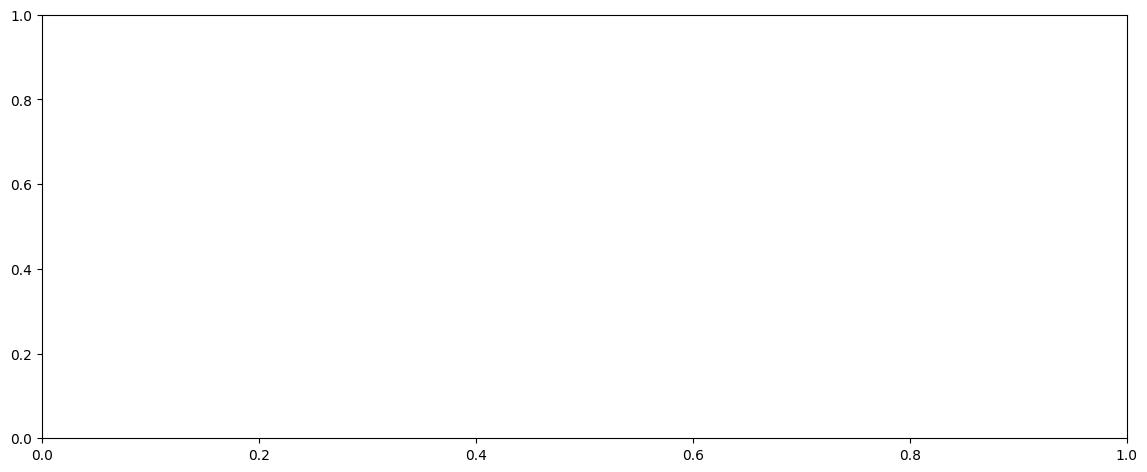

In [22]:
short_names = [SHORT_LABELS[c] for c in CLASSES]

# 9.1 Per-class recall by variant (with CI)
fig, ax = plt.subplots(figsize=(14, 5.5))
width = 0.8 / len(all_results)
x = np.arange(len(CLASSES))
for i, name in enumerate(all_results.keys()):
    per_class = all_results[name]["test"]["per_class_ci"]
    recalls = [per_class.get(c, {}).get("recall", 0) for c in CLASSES]
    errs = [1.96 * per_class.get(c, {}).get("se", 0) for c in CLASSES]
    ax.bar(x + i * width, recalls, width, yerr=errs, capsize=2, label=name)
ax.set_xticks(x + width * (len(all_results) - 1) / 2)
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_ylabel("Test recall (95% CI)")
ax.set_title("Per-class test recall by variant")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "per_class_recall.png", dpi=150)
plt.show()

# 9.2 Accuracy / macro-F1 / ECE by variant
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].scatter(comparison_df["params_M"], comparison_df["test_top1"], s=80)
for _, row in comparison_df.iterrows():
    axes[0].annotate(row["variant"], (row["params_M"], row["test_top1"]), textcoords="offset points", xytext=(5, 5))
axes[0].set_xlabel("Params (M)"); axes[0].set_ylabel("Test top1"); axes[0].set_title("Accuracy vs. model size")
axes[1].bar(comparison_df["variant"], comparison_df["macro_F1"], color="steelblue")
axes[1].set_ylabel("Macro-F1 (test)"); axes[1].set_title("Macro-F1 by variant")
axes[2].bar(comparison_df["variant"], comparison_df["ECE"], color="indianred")
axes[2].set_ylabel("ECE (lower=better)"); axes[2].set_title("Calibration by variant")
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "accuracy_f1_ece.png", dpi=150)
plt.show()

# 9.3 Training curves (loss + top1), all variants
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for name in all_results.keys():
    try:
        df = load_results_csv(name)
    except FileNotFoundError:
        continue
    epoch_col = find_col(df, "epoch") or df.columns[0]
    loss_col = find_col(df, "train", "loss")
    top1_col = find_col(df, "top1") or find_col(df, "accuracy_top1")
    if loss_col:
        axes[0].plot(df[epoch_col], df[loss_col], label=name)
    if top1_col:
        axes[1].plot(df[epoch_col], df[top1_col], label=name)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss"); axes[0].set_title("Train loss by epoch"); axes[0].legend()
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val top1"); axes[1].set_title("Val top1 by epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "training_curves.png", dpi=150)
plt.show()

print("Figures saved:", [p.name for p in (REPORT_DIR / "figures").glob("*.png")])

In [ ]:
import shutil

native_plot_names = [
    "results.png", "confusion_matrix.png", "confusion_matrix_normalized.png", "args.yaml"
]

for name in all_results.keys():
    src_dir = BACKUP_DIR / name
    dst_dir = REPORT_DIR / "figures" / name
    dst_dir.mkdir(parents=True, exist_ok=True)
    for fname in native_plot_names:
        src = src_dir / fname
        if src.exists():
            shutil.copy2(src, dst_dir / fname)
    # per-variant metrics json
    metrics_src = src_dir / "test_metrics.json"
    if metrics_src.exists():
        shutil.copy2(metrics_src, REPORT_DIR / "metrics" / f"{name}_test_metrics.json")

print("Native plots pulled in for:", list(all_results.keys()))

In [ ]:
from IPython.display import FileLink

archive_path = shutil.make_archive(str(WORKING_DIR / "report_bundle"), "zip", root_dir=REPORT_DIR)
size_mb = Path(archive_path).stat().st_size / (1024 * 1024)
print(f"report_bundle.zip: {size_mb:.2f} MB")

# Interactive session: click this link to download directly.
FileLink(archive_path)